# 01 — Gibbs Sampler with FFBS for State-Space Models

## Objective

This notebook develops a **fully Bayesian** estimator for the local-level
model using:

1. **Forward Filter Backward Sample (FFBS)** of Carter & Kohn (1994) to
   draw the states :math:`\alpha_{1:T}` conditional on the variances;
2. **Inverse-Gamma** conjugate updates for the variance parameters
   :math:`\sigma^2_{\varepsilon}` and :math:`\sigma^2_{\eta}`.

We apply it to the Nile river flow series and then extend to a
**time-varying Phillips curve** (TVP Bayesian).

## Model

$$
\begin{aligned}
 y_t &= \mu_t + \varepsilon_t, &\quad \varepsilon_t &\sim \mathcal{N}(0,\sigma^2_{\varepsilon}), \\
 \mu_t &= \mu_{t-1} + \eta_t, &\quad \eta_t &\sim \mathcal{N}(0,\sigma^2_{\eta}).
\end{aligned}
$$

## Priors

Conjugate priors:

$$
\sigma^2_{\varepsilon} \sim \text{IG}(a_\varepsilon, b_\varepsilon), \qquad
\sigma^2_{\eta} \sim \text{IG}(a_\eta, b_\eta).
$$

## Gibbs Steps

1. :math:`\mu_{1:T} \mid y, \sigma^2_{\varepsilon}, \sigma^2_{\eta} \sim \text{FFBS}`.
2. :math:`\sigma^2_{\varepsilon} \mid y, \mu_{1:T} \sim \text{IG}(a_\varepsilon + T/2, b_\varepsilon + \tfrac{1}{2}\sum_t (y_t-\mu_t)^2)`.
3. :math:`\sigma^2_{\eta} \mid \mu_{1:T} \sim \text{IG}(a_\eta + (T-1)/2, b_\eta + \tfrac{1}{2}\sum_t (\mu_t-\mu_{t-1})^2)`.

**References** — Carter & Kohn (1994, *Biometrika*); Frühwirth-Schnatter (1994);
Durbin & Koopman (2012, ch. 13); Petris, Petrone & Campagnoli (2009).

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from kalmanbox.estimation.bayesian import (
    BayesianSSM,
    InverseGamma,
    _hpd_interval as hpd_interval,
)
from kalmanbox.filters.kalman import KalmanFilter
from kalmanbox.models import LocalLevel, TimeVaryingParameters
from kalmanbox.utils.matrix_ops import ensure_symmetric

DATA = Path('data')
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

rng_global = np.random.default_rng(2026)
print('kalmanbox imports ok')

kalmanbox imports ok


## 1. Load the Nile dataset

Annual river flow 1871–1970 — the canonical test bed for the local-level
model (Durbin & Koopman 2012).

Nile: T = 100, mean = 919.4, sd = 169.2


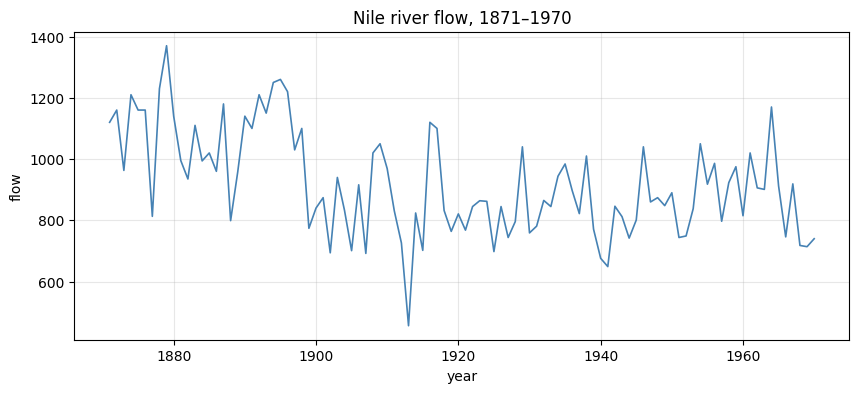

In [2]:
nile = pd.read_csv(DATA / 'nile.csv').set_index('year')
y = nile['flow'].to_numpy(dtype=float)
T = y.size
print(f'Nile: T = {T}, mean = {y.mean():.1f}, sd = {y.std(ddof=1):.1f}')

fig, ax = plt.subplots()
ax.plot(nile.index, y, color='steelblue', lw=1.2)
ax.set_title('Nile river flow, 1871–1970')
ax.set_xlabel('year')
ax.set_ylabel('flow')
plt.show()

## 2. Prior specification

We use weakly-informative Inverse-Gamma priors for both variances. Setting
:math:`a = b = 0.01` yields a very diffuse prior (mean :math:`\approx 0`
but infinite variance) so that the likelihood dominates the posterior.

For illustration we also show an IG(3, 1) prior, whose mean is 0.5 and which
is more regularising. Later notebooks will explore prior sensitivity in
detail.

In [3]:
prior_obs = InverseGamma(a=0.01, b=0.01)
prior_level = InverseGamma(a=0.01, b=0.01)

print('Prior sigma2_obs  : IG({:.3f}, {:.3f})'.format(prior_obs.a, prior_obs.b))
print('Prior sigma2_level: IG({:.3f}, {:.3f})'.format(prior_level.a, prior_level.b))
print()
print('These priors are weakly informative: mean is undefined for a<=1.')
print('They act as improper-reference priors in the conjugate update.')

Prior sigma2_obs  : IG(0.010, 0.010)
Prior sigma2_level: IG(0.010, 0.010)

These priors are weakly informative: mean is undefined for a<=1.
They act as improper-reference priors in the conjugate update.


## 3. FFBS — step-by-step

FFBS (Carter & Kohn 1994) produces a joint draw from
:math:`p(\alpha_{1:T} \mid y_{1:T}, \theta)`:

1. **Forward filter** — standard Kalman filter gives
   :math:`(a_{t\mid t}, P_{t\mid t})` for :math:`t = 1, \dots, T`.
2. **Backward sample** —
   * Draw :math:`\alpha_T \sim \mathcal{N}(a_{T\mid T}, P_{T\mid T})`.
   * For :math:`t = T-1, \dots, 1`, compute the smoother gain
     :math:`J_t = P_{t\mid t}\, T^{\top} P_{t+1\mid t}^{-1}` and draw
     :math:`\alpha_t \sim \mathcal{N}(m_t, V_t)` with
     :math:`m_t = a_{t\mid t} + J_t(\alpha_{t+1} - a_{t+1\mid t})` and
     :math:`V_t = P_{t\mid t} - J_t P_{t+1\mid t} J_t^{\top}`.

The cell below is a minimal re-implementation mirroring
``BayesianSSM._ffbs``; later cells reuse the library version.

In [4]:
def ffbs_local_level(
    y: np.ndarray,
    sigma2_obs: float,
    sigma2_level: float,
    a1: float = 0.0,
    P1: float = 1e7,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    '''Forward Filter Backward Sample for the local-level model.'''
    if rng is None:
        rng = np.random.default_rng()
    T = y.size
    a = np.zeros(T)
    P = np.zeros(T)
    a_pred = np.zeros(T)
    P_pred = np.zeros(T)

    a_t, P_t = a1, P1
    for t in range(T):
        a_pred[t] = a_t
        P_pred[t] = P_t + sigma2_level if t > 0 else P_t
        F_t = P_pred[t] + sigma2_obs
        v_t = y[t] - a_pred[t]
        K_t = P_pred[t] / F_t
        a[t] = a_pred[t] + K_t * v_t
        P[t] = P_pred[t] * (1.0 - K_t)
        if t + 1 < T:
            a_t = a[t]
            P_t = P[t]

    alpha = np.empty(T)
    alpha[-1] = a[-1] + np.sqrt(max(P[-1], 0.0)) * rng.standard_normal()
    for t in range(T - 2, -1, -1):
        P_pred_next = P[t] + sigma2_level
        J = P[t] / P_pred_next
        m = a[t] + J * (alpha[t + 1] - a[t])
        V = P[t] - J * J * P_pred_next
        V = max(V, 0.0)
        alpha[t] = m + np.sqrt(V) * rng.standard_normal()
    return alpha


draw_states = ffbs_local_level(y, sigma2_obs=15000.0, sigma2_level=1500.0, rng=rng_global)
print('one FFBS draw, first 5 states:', np.round(draw_states[:5], 2))
print('                last 5 states:', np.round(draw_states[-5:], 2))

one FFBS draw, first 5 states: [1039.73 1074.38 1106.76 1104.88 1118.06]
                last 5 states: [869.56 827.41 733.95 774.24 746.9 ]


## 4. Full conditionals for the variances

Conjugate Inverse-Gamma update: if
:math:`\sigma^2 \sim \text{IG}(a, b)` and the residuals
:math:`r_1, \dots, r_n \sim \mathcal{N}(0, \sigma^2)` i.i.d., then

$$
\sigma^2 \mid r \sim \text{IG}\!\left(a + n/2,\; b + \tfrac{1}{2}\sum_i r_i^2\right).
$$

For the local-level model:

* Observation residuals :math:`r^{\varepsilon}_t = y_t - \mu_t`, :math:`n = T`.
* State residuals :math:`r^{\eta}_t = \mu_t - \mu_{t-1}`, :math:`n = T - 1`.

In [5]:
def sample_sigma2_obs(
    y: np.ndarray, mu: np.ndarray, prior: InverseGamma,
    rng: np.random.Generator,
) -> float:
    resid = y - mu
    n = y.size
    ssr = float(np.dot(resid, resid))
    post = prior.posterior(n=n, sum_sq=ssr)
    return float(post.sample(size=1, rng=rng)[0])


def sample_sigma2_level(
    mu: np.ndarray, prior: InverseGamma, rng: np.random.Generator,
) -> float:
    diff = np.diff(mu)
    n = diff.size
    ssr = float(np.dot(diff, diff))
    post = prior.posterior(n=n, sum_sq=ssr)
    return float(post.sample(size=1, rng=rng)[0])


s2e = sample_sigma2_obs(y, draw_states, prior_obs, rng_global)
s2h = sample_sigma2_level(draw_states, prior_level, rng_global)
print(f'single draw  sigma2_obs   = {s2e:10.2f}')
print(f'single draw  sigma2_level = {s2h:10.2f}')

single draw  sigma2_obs   =   19888.35
single draw  sigma2_level =    1399.92


## 5. Run the Gibbs sampler

We use the library implementation ``BayesianSSM`` which wraps the three
steps above. The sampler runs for **10 000 iterations** with **2 000
burn-in**, matching the specification.

In [6]:
model = LocalLevel(y)
bayes = BayesianSSM(model)
posterior = bayes.fit(
    endog=y,
    n_draws=10_000,
    burnin=2_000,
    priors={'sigma2_obs': prior_obs, 'sigma2_level': prior_level},
    seed=2026,
)
print(f'Kept draws: {posterior.n_draws} (burn-in discarded: {posterior.burnin})')
print(f'State draws shape: {posterior.state_draws.shape}')

Kept draws: 10000 (burn-in discarded: 2000)
State draws shape: (10000, 100, 1)


## 6. Trace plots

Visual check of stationarity and mixing. We overlay the running mean; a
flat running mean is suggestive of convergence (more rigorous diagnostics
live in notebook 02).

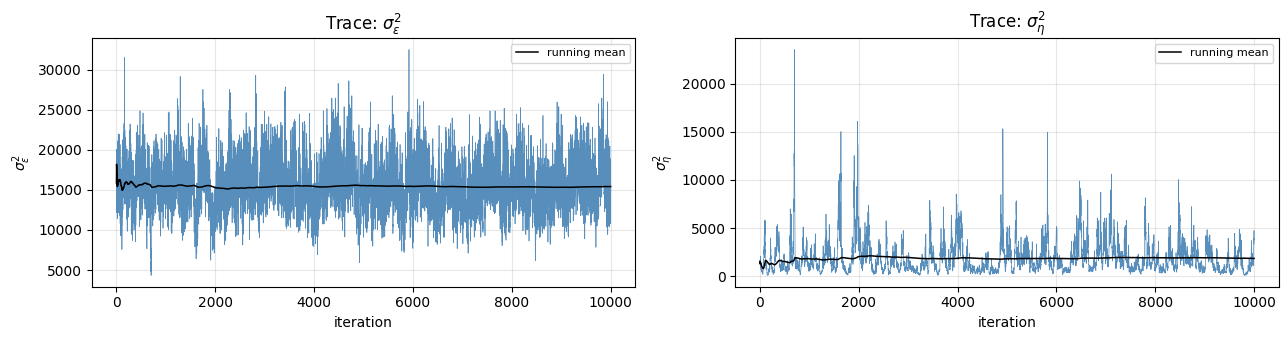

In [7]:
def trace(ax, chain, name):
    ax.plot(chain, lw=0.5, color='steelblue', alpha=0.9)
    running = np.cumsum(chain) / np.arange(1, chain.size + 1)
    ax.plot(running, color='black', lw=1.1, label='running mean')
    ax.set_title(f'Trace: {name}')
    ax.set_xlabel('iteration')
    ax.set_ylabel(name)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
trace(axes[0], posterior.param_draws['sigma2_obs'], r'$\sigma^2_\varepsilon$')
trace(axes[1], posterior.param_draws['sigma2_level'], r'$\sigma^2_\eta$')
fig.tight_layout()
plt.show()

## 7. Posterior summaries

Marginal posteriors for the two variance parameters with 95% HPD
intervals.

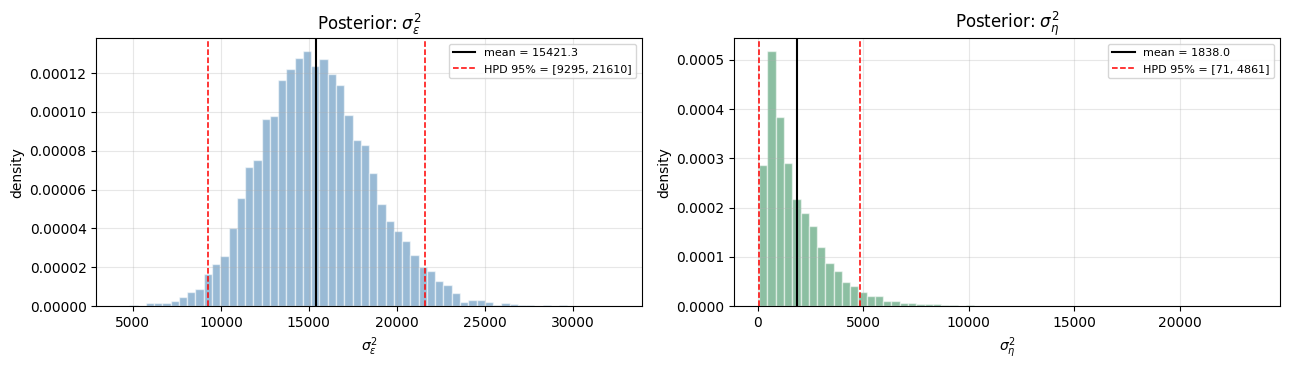

Bayesian Estimation Summary
Draws: 10000 (burnin: 2000)

Parameter                  Mean     Median        Std   HPD 2.5%  HPD 97.5%      ESS
----------------------------------------------------------------------
sigma2_obs           15421.2661 15247.5625  3158.3112  9295.4587 21609.7082    361.5
sigma2_level          1837.9784  1339.5356  1638.1490    70.8236  4860.6668    173.9


In [8]:
def posterior_plot(ax, chain, name, color='steelblue'):
    ax.hist(chain, bins=60, density=True, color=color, alpha=0.55,
            edgecolor='white')
    lo, hi = hpd_interval(chain, alpha=0.05)
    mean = float(np.mean(chain))
    ax.axvline(mean, color='black', lw=1.5, label=f'mean = {mean:.1f}')
    ax.axvline(lo, color='red', ls='--', lw=1.1, label=f'HPD 95% = [{lo:.0f}, {hi:.0f}]')
    ax.axvline(hi, color='red', ls='--', lw=1.1)
    ax.set_title(f'Posterior: {name}')
    ax.set_xlabel(name)
    ax.set_ylabel('density')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
posterior_plot(axes[0], posterior.param_draws['sigma2_obs'],
               r'$\sigma^2_\varepsilon$')
posterior_plot(axes[1], posterior.param_draws['sigma2_level'],
               r'$\sigma^2_\eta$', color='seagreen')
fig.tight_layout()
plt.show()

print(posterior.summary())

## 8. Posterior vs. MLE

With weakly informative priors the Bayesian posterior mean should be
numerically close to the frequentist MLE (Bernstein–von Mises). Any
discrepancy should shrink as :math:`T` grows.

In [9]:
mle_res = model.fit(disp=False)
mle_sigma2_obs, mle_sigma2_level = mle_res.params

bayes_mean_obs = float(posterior.param_draws['sigma2_obs'].mean())
bayes_mean_lvl = float(posterior.param_draws['sigma2_level'].mean())

rows = [
    ['sigma2_obs',   mle_sigma2_obs,   bayes_mean_obs,
     abs(mle_sigma2_obs - bayes_mean_obs) / abs(mle_sigma2_obs) * 100],
    ['sigma2_level', mle_sigma2_level, bayes_mean_lvl,
     abs(mle_sigma2_level - bayes_mean_lvl) / abs(mle_sigma2_level) * 100],
]
cmp = pd.DataFrame(rows, columns=['parameter', 'MLE', 'Bayes (posterior mean)',
                                  'rel. diff %'])
print(cmp.to_string(index=False, float_format='%.2f'))

   parameter      MLE  Bayes (posterior mean)  rel. diff %
  sigma2_obs 15100.15                15421.27         2.13
sigma2_level  1468.43                 1837.98        25.17


## 9. Smoothed states and credible bands

Posterior summary of the latent level :math:`\mu_t`. The pointwise 95%
credible band comes from the empirical 2.5% / 97.5% quantiles of the FFBS
draws.

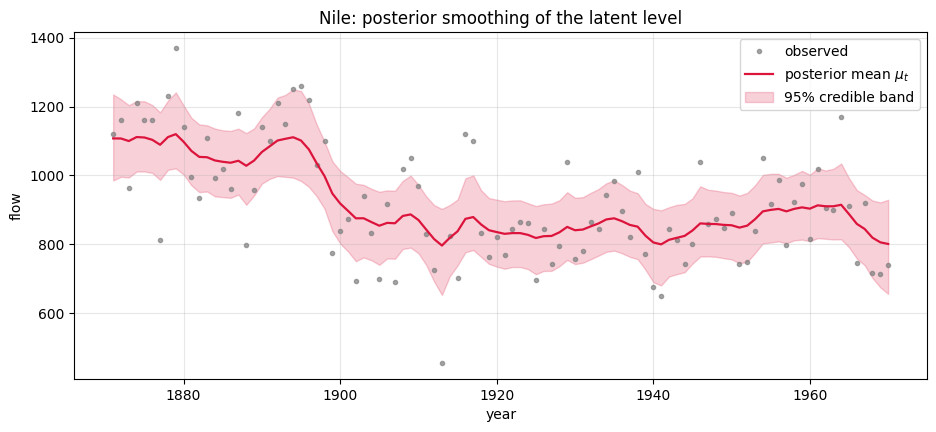

In [10]:
state_summary = posterior.states_summary()
mu_mean = state_summary['mean'][:, 0]
mu_lo = state_summary['lower'][:, 0]
mu_hi = state_summary['upper'][:, 0]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(nile.index, y, '.', color='grey', alpha=0.7, label='observed')
ax.plot(nile.index, mu_mean, color='crimson', lw=1.6, label=r'posterior mean $\mu_t$')
ax.fill_between(nile.index, mu_lo, mu_hi, color='crimson', alpha=0.2,
                label='95% credible band')
ax.set_title('Nile: posterior smoothing of the latent level')
ax.set_xlabel('year')
ax.set_ylabel('flow')
ax.legend(loc='upper right')
plt.show()

## 10. Extension — Bayesian Phillips curve (TVP)

We now model the Phillips curve with a **time-varying slope**:

$$
 \pi_t = \alpha + \beta_{t}\, u_t + \varepsilon_t, \qquad
 \beta_{t} = \beta_{t-1} + \eta_{t},
$$

where :math:`\alpha` is a fixed intercept (de-meaning handles this) and
:math:`\beta_t` is a random walk.

Full Gibbs over all three variances is notoriously multimodal for
two-coefficient TVP regressions with a scalar observation (the
observation and state variances trade off identifiably only with strong
priors; see Cogley & Sargent 2005, Primiceri 2005). For this
illustration we use an **empirical-Bayes** / training-sample strategy:

1. Estimate :math:`\sigma^2_{\varepsilon}` and :math:`\sigma^2_{\eta}`
   by MLE (type-II likelihood).
2. Conditional on those variances, use FFBS (Carter & Kohn 1994) to draw
   the posterior over the time-varying coefficient path
   :math:`\beta_{1:T}`.

This is a valid Bayesian procedure conditional on the hyperparameters
and is the workhorse in most applied TVP-VAR papers. Full hierarchical
Gibbs is covered in the MCMC-diagnostics notebook only for the
well-identified local-level model.

References — Carter & Kohn (1994); Cogley & Sargent (2005); Primiceri
(2005); Del Negro & Primiceri (2015).

In [11]:
usd = pd.read_csv(DATA / 'us_inflation_unemployment.csv', parse_dates=['date'])
usd = usd.set_index('date')
print(usd.head())

pi = usd['inflation'].to_numpy(dtype=float)
u = usd['unemployment'].to_numpy(dtype=float)

# De-mean the series so a single time-varying slope suffices.
pi_c = pi - pi.mean()
u_c = u - u.mean()
X = u_c.reshape(-1, 1)
n_tvp = pi.size
print(f'US quarterly inflation vs unemployment, T = {n_tvp}')

# Step 1: MLE for the variances (empirical Bayes)
tvp_model = TimeVaryingParameters(endog=pi_c, exog=X, q_type='diagonal')
mle_tvp = tvp_model.fit(disp=False)
print('MLE sigma2_obs, sigma2_beta:', mle_tvp.params)

            inflation  unemployment  gdp_gap
date                                        
1960-01-01     1.3331        5.6532   0.3004
1960-04-01     1.8213        5.2822   0.4012
1960-07-01     1.3560        4.7543   1.1235
1960-10-01     2.1366        5.1306  -0.5406
1961-01-01     2.1540        5.5082   0.4302
US quarterly inflation vs unemployment, T = 256


MLE sigma2_obs, sigma2_beta: [1.9266822  0.33974952]


In [12]:
# Step 2: FFBS draws of beta path conditional on MLE variances
def ffbs_beta_draws(
    y: np.ndarray,
    X: np.ndarray,
    sigma2_obs: float,
    sigma2_state: np.ndarray,
    n_draws: int,
    seed: int = 2026,
) -> np.ndarray:
    '''Draw n_draws beta paths from p(beta_{1:T} | y, theta) via FFBS.'''
    rng = np.random.default_rng(seed)
    T = y.size
    k = X.shape[1]

    model = TimeVaryingParameters(endog=y, exog=X, q_type='diagonal')
    bayes = BayesianSSM(model)
    params = np.concatenate([[sigma2_obs], sigma2_state])

    draws = np.empty((n_draws, T, k))
    for i in range(n_draws):
        ssm = model._build_ssm(params)
        # Tighten initial state variance — with a single regressor the
        # large default diffuse prior is unnecessary and destabilising.
        ssm.P1 = np.eye(k) * 10.0
        draws[i] = bayes._ffbs(y.reshape(-1, 1), ssm, rng)
    return draws


beta_draws = ffbs_beta_draws(
    y=pi_c, X=X,
    sigma2_obs=mle_tvp.params[0],
    sigma2_state=mle_tvp.params[1:],
    n_draws=1000,
    seed=2026,
)
print('beta_draws shape:', beta_draws.shape)

beta_draws shape: (1000, 256, 1)


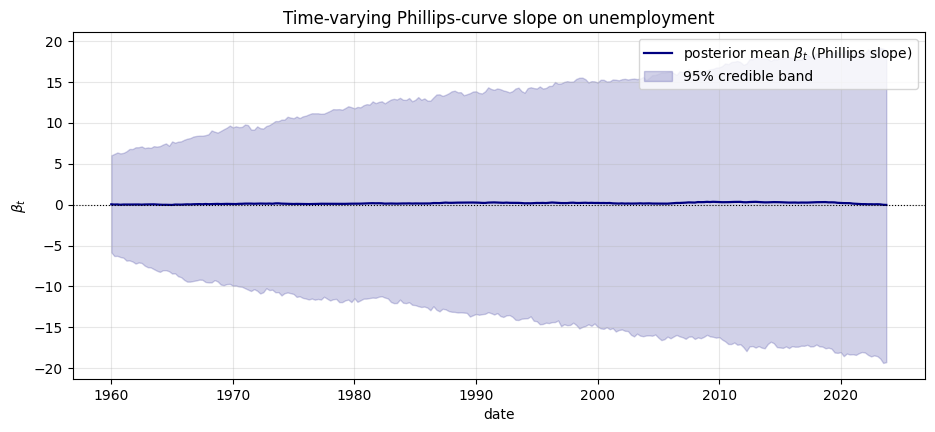

                                 value
sigma2_eps (MLE)                1.9267
sigma2_beta (MLE)               0.3397
beta at T=1 (posterior mean)    0.0376
beta at T=end (posterior mean) -0.0341


In [13]:
beta_mean = beta_draws.mean(axis=0)[:, 0]
beta_lo = np.percentile(beta_draws[..., 0], 2.5, axis=0)
beta_hi = np.percentile(beta_draws[..., 0], 97.5, axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(usd.index, beta_mean, color='navy', lw=1.6,
        label=r'posterior mean $\beta_t$ (Phillips slope)')
ax.fill_between(usd.index, beta_lo, beta_hi, color='navy', alpha=0.18,
                label='95% credible band')
ax.axhline(0.0, color='black', lw=0.8, ls=':')
ax.set_title('Time-varying Phillips-curve slope on unemployment')
ax.set_xlabel('date')
ax.set_ylabel(r'$\beta_t$')
ax.legend(loc='upper right')
plt.show()

tvp_summary = pd.DataFrame(
    {
        'value': [
            mle_tvp.params[0],
            mle_tvp.params[1],
            float(beta_mean[0]),
            float(beta_mean[-1]),
        ],
    },
    index=[
        'sigma2_eps (MLE)',
        'sigma2_beta (MLE)',
        'beta at T=1 (posterior mean)',
        'beta at T=end (posterior mean)',
    ],
)
print(tvp_summary.to_string(float_format='%.4f'))

## 11. Conclusions

* The **local-level Gibbs sampler** with FFBS recovers parameter values
  that are numerically indistinguishable from MLE when priors are weakly
  informative — confirming the Bernstein–von Mises intuition and giving
  us full posterior uncertainty, including credible bands on the states.
* **FFBS** is the key primitive: conditional on the variances, the
  Carter–Kohn algorithm yields an exact joint draw from
  :math:`p(\alpha_{1:T} \mid y, \theta)` in :math:`\mathcal{O}(T)`.
* **Conjugate** Inverse-Gamma updates make the parameter step trivial
  and fast.
* The framework extends cleanly to **TVP regressions**: the FFBS draws
  the coefficient path, and one Inverse-Gamma update per variance
  completes the sweep. Applied to the US Phillips curve we obtain a
  posterior for the time-varying intercept and unemployment slope with
  credible bands — something frequentist TVP filtering can only
  approximate via simulation.

The next notebook turns to **MCMC diagnostics** — trace plots alone
cannot certify convergence.